# Stage 5 — Cluster Pooling

**Input**: `adata.h5ad` (Stage 3) + `cluster_labels.csv` (Stage 4)  
**Output**: Updated dot plot/heatmap with human-assigned labels, `adata_pooled.h5ad`, per-ROI CSVs  
**Scope**: Per machine

This stage applies the human-assigned labels from Stage 4 and regenerates the Stage 3 dot plot and heatmap with meaningful cell-type names (for intermediate reporting). It also prepares the pooled AnnData for Stage 6.

In [8]:
import numpy as np
import pandas as pd
from IPython.display import display

from pipeline.config import load_config
from pipeline.io import (
    load_adata,
    save_adata,
    load_cluster_labels,
    save_roi_assignments,
    validate_stage_inputs,
)
from pipeline.preprocessing import double_z_norm
from pipeline.clustering import apply_cluster_labels, prepare_cluster_means
from pipeline.visualization import plot_dotplot, plot_heatmap

cfg = load_config("config.yaml")

In [ ]:
# ── Select machine ──
MACHINE = list(cfg.machines.keys())[1]
print(f"Selected machine: {MACHINE}")

stage3_dir = cfg.stage_dir(3, MACHINE)
stage4_dir = cfg.stage_dir(4, MACHINE)
stage5_dir = cfg.ensure_stage_dir(5, MACHINE)

validate_stage_inputs(
    [stage3_dir / "adata.h5ad", stage4_dir / "cluster_labels.csv"],
    "Stage 5",
)

Selected machine: machine_A
[Stage 5] All required inputs found ✓


## Apply Labels & Generate Labelled Plots

In [3]:
# Load Stage 3 AnnData and Stage 4 labels
adata = load_adata(stage3_dir / "adata.h5ad")
labels_df = load_cluster_labels(stage4_dir / "cluster_labels.csv")

print("Cluster labels from Stage 4:")
display(labels_df)

# Apply labels and groups to AnnData
adata = apply_cluster_labels(adata, labels_df, cluster_key="leiden")

# Identify feature columns
selected_markers = cfg.selected_markers
meta_columns = cfg.meta_columns
all_obs_cols = set(adata.obs.columns)
known_cols = set(meta_columns) | set(selected_markers) | {
    "leiden", "cluster_label", "cluster_group", "cluster_labelled"
}
unselected_features = sorted(all_obs_cols - known_cols)

print(f"\nApplied labels. Unique groups: {adata.obs['cluster_group'].unique().tolist()}")

Cluster labels from Stage 4:


/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,cluster_id,label,group
0,0,Granluocyte,Myeloid
1,1,Monocytes,Myeloid
2,2,MSC,MSC
3,3,NPM1-positive/Erythroid,Tumor/Erythroid
4,4,Erythroid,Tumor/Erythroid
5,5,Tumor,Tumor
6,6,Erythroid,Erythroid
7,7,Granulocyte,Myeloid
8,8,CD8 T cell,T cells
9,9,Monocytes/CD4+ T,Myeloid



Applied labels. Unique groups: ['Myeloid', 'Endothelial', 'Mixed Lymphoid', 'Tumor/Erythroid', 'T cells', 'B cells', 'Erythroid', 'Tumor', 'Megakaryocytes', 'Unknown', 'MSC']


/home/hp/projects/multiplex_imaging_analysis/pipeline/clustering.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = expr_df.groupby(cluster_key).mean()


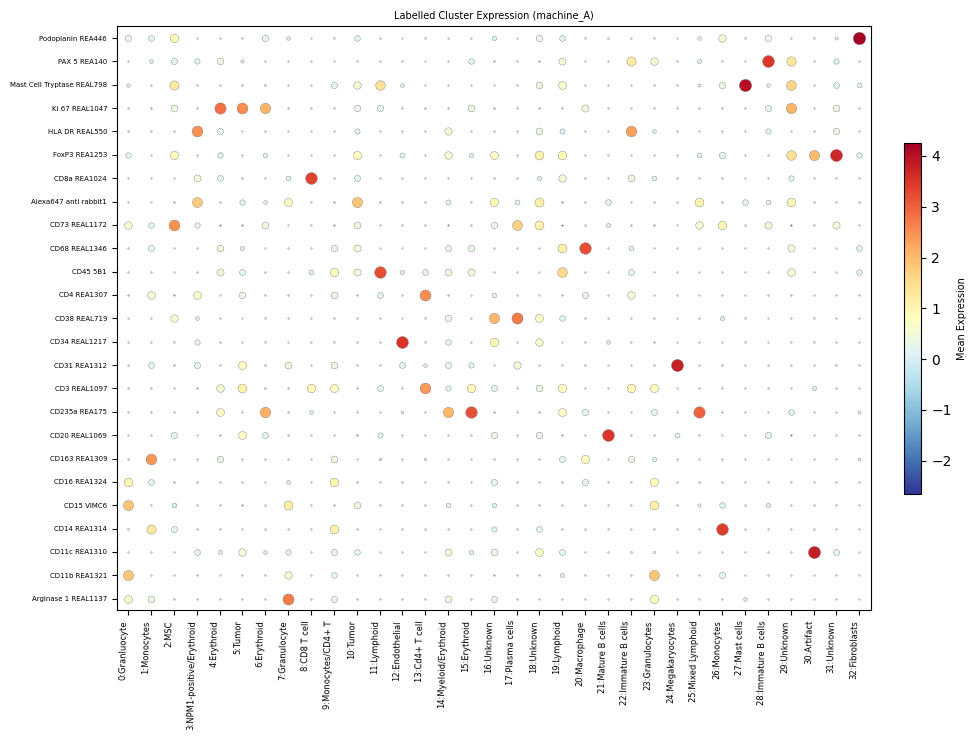

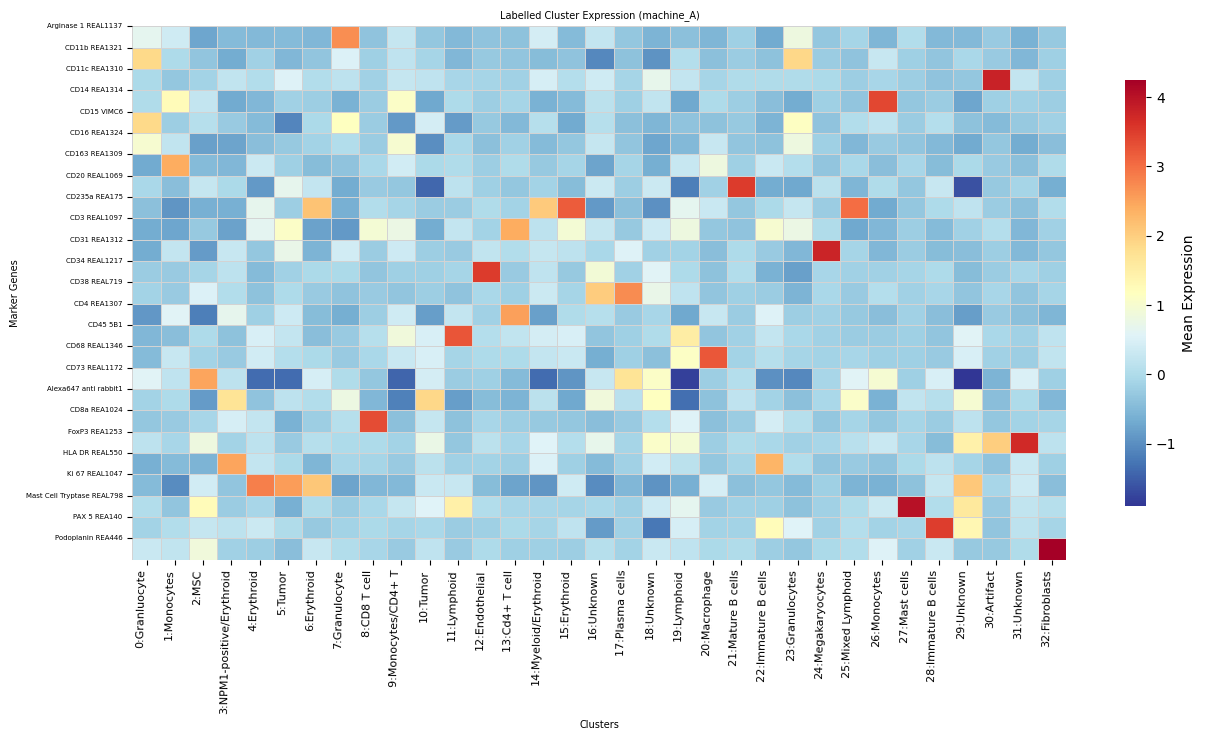

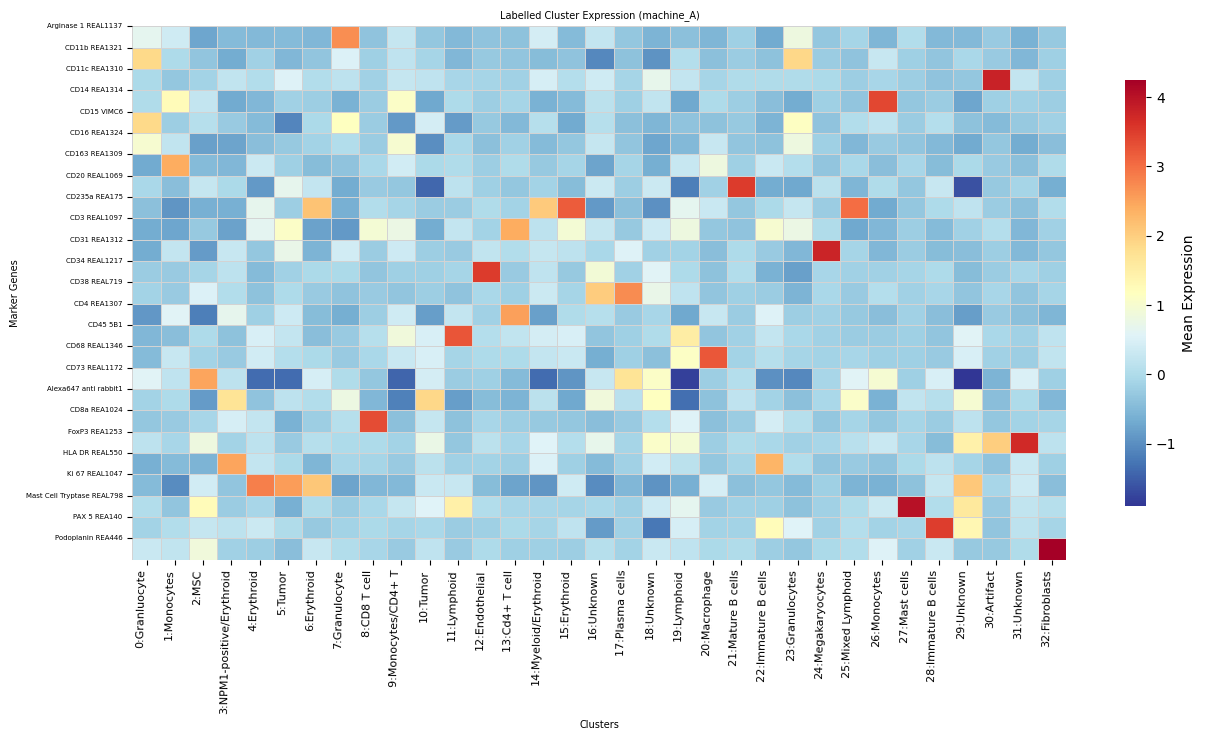

In [5]:
# Build labelled cluster means (cluster_id:label format)
label_map = dict(zip(labels_df["cluster_id"].astype(str), labels_df["label"]))
cluster_means = prepare_cluster_means(
    adata, selected_markers, unselected_features,
    cluster_key="leiden", custom_labels={int(k): v for k, v in label_map.items()},
)

x_labels = cluster_means.index.tolist()
y_labels = list(selected_markers)

# Updated dot plot with human-assigned labels
plot_dotplot(
    cluster_means, x_labels, y_labels,
    save_path=stage5_dir / "dotplot_labelled.svg",
    title=f"Labelled Cluster Expression ({MACHINE})",
)

# Updated heatmap with human-assigned labels
plot_heatmap(
    cluster_means, x_labels, y_labels,
    save_path=stage5_dir / "heatmap_labelled.svg",
    title=f"Labelled Cluster Expression ({MACHINE})",
)

## Save Pooled Outputs

In [7]:
# Save pooled cluster means
cluster_means.to_csv(stage5_dir / "pooled_means.csv")

# Save updated AnnData with labels and groups
save_adata(adata, stage5_dir / "adata_pooled.h5ad")

# Save per-ROI cluster assignment CSVs (with labels)
roi_dir = stage5_dir / "roi_assignments"
save_roi_assignments(adata, roi_dir, region_col="unique_region")

print(f"\n✓ Stage 5 complete for machine '{MACHINE}'")
print(f"  Outputs: {stage5_dir}")
print(f"  - dotplot_labelled.svg (Stage 3 dotplot with human labels)")
print(f"  - heatmap_labelled.svg (Stage 3 heatmap with human labels)")
print(f"  - adata_pooled.h5ad")
print(f"  - roi_assignments/")

Saved AnnData → experiments/exp-04-03-2026/stage5_pooled/machine_A/adata_pooled.h5ad
Saved 34 per-ROI assignment files → experiments/exp-04-03-2026/stage5_pooled/machine_A/roi_assignments

✓ Stage 5 complete for machine 'machine_A'
  Outputs: experiments/exp-04-03-2026/stage5_pooled/machine_A
  - dotplot_labelled.svg (Stage 3 dotplot with human labels)
  - heatmap_labelled.svg (Stage 3 heatmap with human labels)
  - adata_pooled.h5ad
  - roi_assignments/
